In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/Users/ismail/GitHub Projects/Bounties/Data_source/Completed_Bounties.csv')
df['Platform'] = df['Name'].str.split('-').str[0]
df['Start Date'] = pd.to_datetime(df['Start Date'], errors='coerce')
df['Year'] = df['Start Date'].dt.year


print(f"TOTAL BOUNTIES {len(df)}")
print(f"\nCOLUMNS ARE {list(df.columns)}")

print("\nBOUNTIES BY LEVEL:")
print(df['Level'].value_counts(normalize=True).mul(100).map("{:.1f}%".format))

TOTAL BOUNTIES 384

COLUMNS ARE ['Name', 'Bounty Title', 'Description', 'Level', 'Start Date', 'End Date', 'Submission Status', 'Batch', 'Platform', 'Year']

BOUNTIES BY LEVEL:
Level
Intermediate    45.6%
Beginner        36.2%
Advanced        18.2%
Name: proportion, dtype: object


In [13]:
def count_and_print(category_dict, title):
    counts = {
        name: all_text.str.contains(pattern, case=False, regex=True).sum()
        for name, pattern in category_dict.items()
    }
    counts = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True))
    
    print(f"\n{title}")
    for name, count in counts.items():
        pct = (count / len(df) * 100)
        print(f"{name:20} {count:4} ({pct:5.1f}%)")
    
    return counts

skill_counts    = count_and_print(skills,    "HOT SKILLS & TOPICS MENTIONED IN BOUNTIES")
topic_counts    = count_and_print(topics,    "HOT TOPICS MENTIONED IN BOUNTIES")
protocol_counts = count_and_print(protocols, "HOT PROTOCOLS MENTIONED IN BOUNTIES")
chain_counts    = count_and_print(chains,    "MOST CHAINS MENTIONED IN BOUNTIES")
metric_counts   = count_and_print(metrics,   "MOST METRICS MENTIONED IN BOUNTIES")


HOT SKILLS & TOPICS MENTIONED IN BOUNTIES
Dashboard             139 ( 36.2%)
Visualization         112 ( 29.2%)
Data Analysis          89 ( 23.2%)
Statistics             51 ( 13.3%)
Flipside               47 ( 12.2%)
Research               36 (  9.4%)
Smart Contract         14 (  3.6%)
Dune                   13 (  3.4%)
Subgraph               10 (  2.6%)
Machine Learning        3 (  0.8%)
SQL                     1 (  0.3%)
Python                  0 (  0.0%)

HOT TOPICS MENTIONED IN BOUNTIES
Liquidity              41 ( 10.7%)
Staking                36 (  9.4%)
NFT                    28 (  7.3%)
DAO                    24 (  6.2%)
DEX                    22 (  5.7%)
DeFi                   19 (  4.9%)
Bridge                 17 (  4.4%)
Governance             17 (  4.4%)
Swap                   15 (  3.9%)
Lending                14 (  3.6%)
TVL                    12 (  3.1%)
Yield                  11 (  2.9%)
Layer 2                 6 (  1.6%)
AMM                     5 (  1.3%)
Gaming       

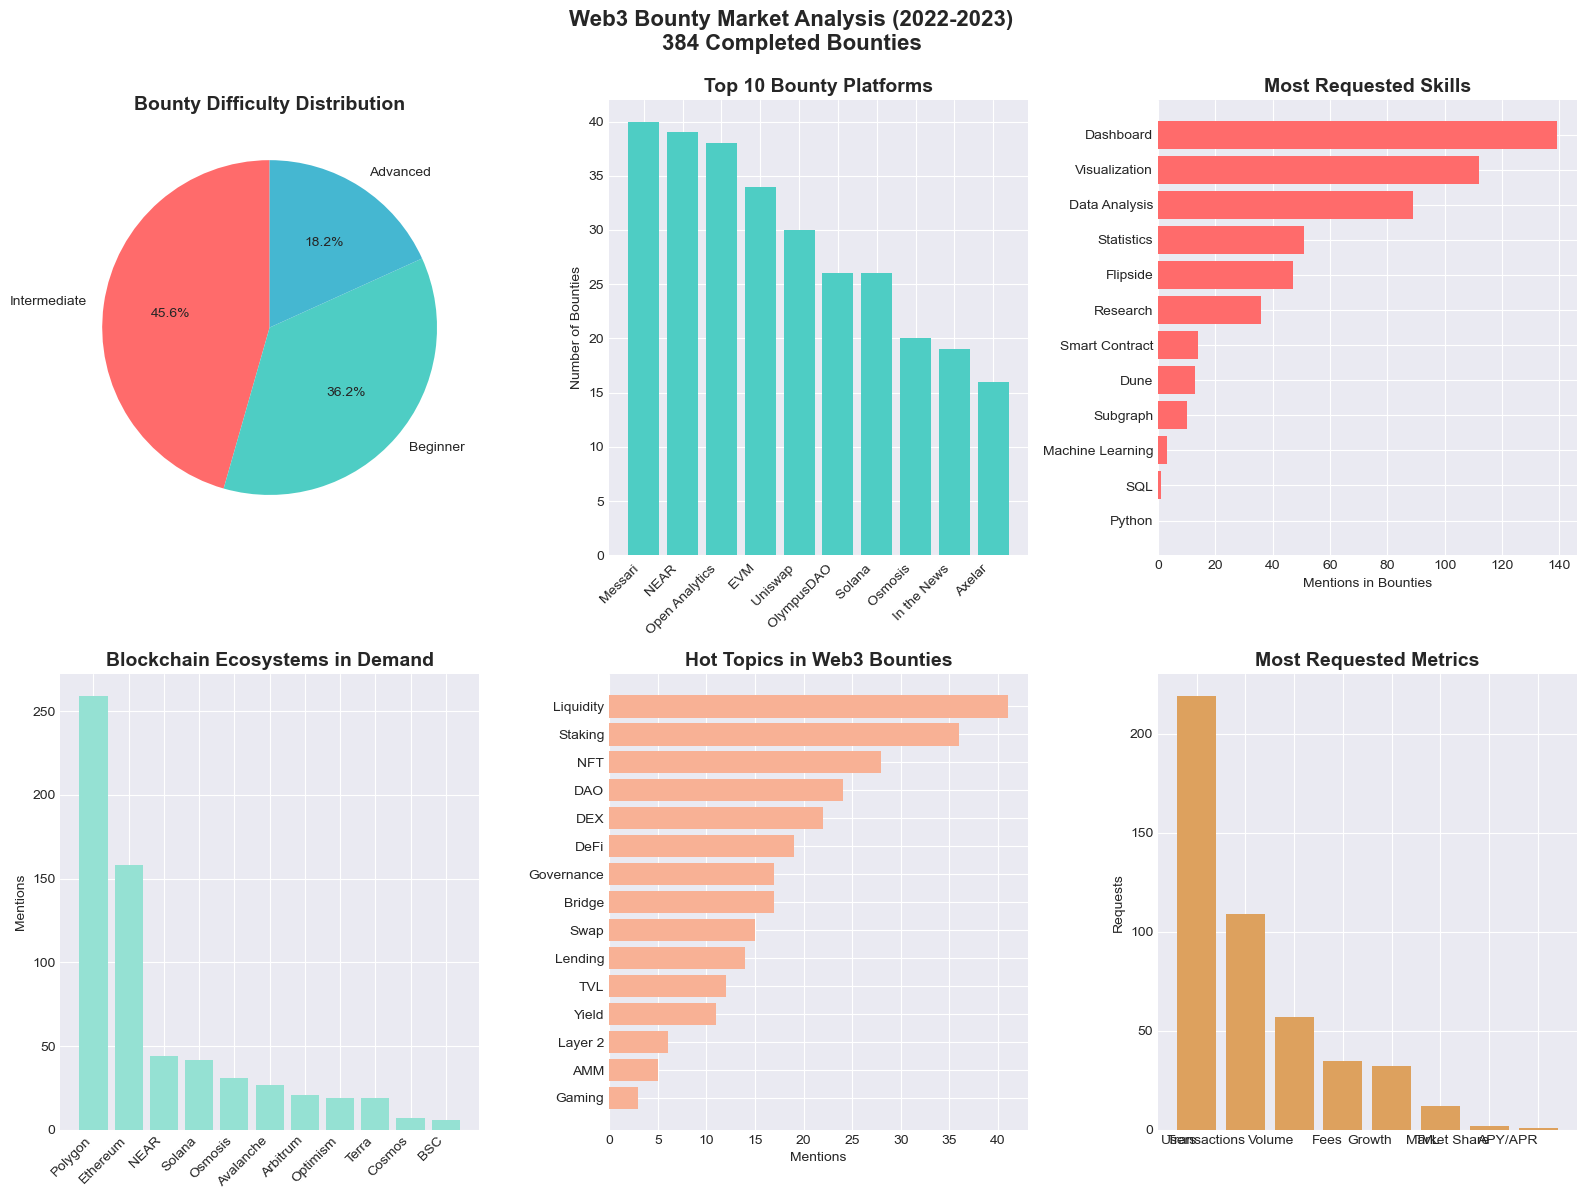

In [5]:
plt.style.use('seaborn-v0_8-darkgrid')
fig = plt.figure(figsize=(16, 12))

COLORS = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#95E1D3', '#F8B195', '#DDA15E']

def make_df(count_dict, col_name):
    return pd.DataFrame(list(count_dict.items()), columns=[col_name, 'Count'])

def barh_plot(ax, count_dict, col_name, xlabel, title, color):
    df_plot = make_df(count_dict, col_name).sort_values('Count', ascending=True)
    ax.barh(df_plot[col_name], df_plot['Count'], color=color)
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=14, fontweight='bold')

def bar_plot(ax, count_dict, col_name, ylabel, title, color, rotation=45):
    df_plot = make_df(count_dict, col_name).sort_values('Count', ascending=False)
    ax.bar(df_plot[col_name], df_plot['Count'], color=color)
    ax.set_xticks(range(len(df_plot)))  # ← add this line
    ax.set_xticklabels(df_plot[col_name], rotation=rotation, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=14, fontweight='bold')


ax1 = plt.subplot(2, 3, 1)
difficulty_counts = df['Level'].value_counts()
ax1.pie(difficulty_counts, labels=difficulty_counts.index, autopct='%1.1f%%',
        colors=COLORS[:3], startangle=90)
ax1.set_title('Bounty Difficulty Distribution', fontsize=14, fontweight='bold')


ax2 = plt.subplot(2, 3, 2)
bar_plot(ax2, df['Platform'].value_counts().head(10).to_dict(),
         'Platform', 'Number of Bounties', 'Top 10 Bounty Platforms', COLORS[1])

ax3 = plt.subplot(2, 3, 3)
barh_plot(ax3, skill_counts, 'Skill', 'Mentions in Bounties', 'Most Requested Skills', COLORS[0])

ax4 = plt.subplot(2, 3, 4)
bar_plot(ax4, chain_counts, 'Chain', 'Mentions', 'Blockchain Ecosystems in Demand', COLORS[3])

ax5 = plt.subplot(2, 3, 5)
barh_plot(ax5, topic_counts, 'Topic', 'Mentions', 'Hot Topics in Web3 Bounties', COLORS[4])

ax6 = plt.subplot(2, 3, 6)
bar_plot(ax6, metric_counts, 'Metric', 'Requests', 'Most Requested Metrics', COLORS[5], rotation=0)

plt.suptitle('Web3 Bounty Market Analysis (2022-2023)\n384 Completed Bounties',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('bounty_analysis_charts.png', dpi=300, bbox_inches='tight')